In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import glob

In [33]:
batch_sizes = (32, 64, 128)
modes = ('onfly', 'preload')

In [34]:
data_dir = os.path.join(os.getcwd(), 'final_data_analysis', 'energy_data')
plot_dir = os.path.join(os.getcwd(), 'final_plots', 'energy')

In [35]:
data_files = glob.glob(os.path.join(data_dir, "*.csv"))

In [36]:
# files for whole training
training_files = [f for f in data_files if "full_rank" in f ]

In [37]:
print(f"Number of training files: {len(training_files)}")

Number of training files: 18


In [38]:
def get_params_from_filename(file):
    """
    Inputs:
        file: str, full file path
    Outputs:
        batch_size: int
        num_workers: int
        num_samples: int
        repeat: int
    """
    file_name = os.path.basename(file)
    
    batch_size = int(file_name.split("_batch-")[1].split("_work-")[0])
    num_workers = int(file_name.split("_work-")[1].split("_samples-")[0])
    num_samples = int(file_name.split("_samples-")[1].split("_repeat-")[0])
    repeat = int(file_name.split("_repeat-")[1].split("_labels-")[0])
    total_samples = num_samples * repeat
    mode = file_name.split("_cc")[0].split("_")[-1]

    return batch_size, num_workers, total_samples, mode

In [39]:
def bar_plot_per_mode(data_onfly, data_preload, col_to_plot):
    fig, ax = plt.subplots(figsize=(5, 3))

    label_locs = np.arange(len(batch_sizes))  # the label locations
    width = 0.25  # the width of the bars


    bar_time_data = {"on-the-fly": data_onfly.groupby(["batch_size"])[col_to_plot].mean(),
                    "before training": data_preload.groupby(["batch_size"])[col_to_plot].mean()
                    } # {mode: [mean 32, mean 64, mean 128]}

    multiplier = 0

    for attribute, measurement in bar_time_data.items():
        offset = multiplier*width + multiplier*0.05
        rects = ax.bar(label_locs + offset, measurement, width, label=attribute)
        multiplier += 1

    ax.set_xticks(label_locs + width/2 + 0.025, batch_sizes)
    return fig, ax

Create a dataframe containing all data per training executed.

In [40]:
# combine data
data_cc = pd.DataFrame()

for f in training_files:
    # get params
    batch_size, num_workers, num_samples, mode = get_params_from_filename(f)

    data = pd.read_csv(f)

    # add params as a column
    data["num_workers"] = [num_workers]
    data["batch_size"] = [batch_size]
    data["num_samples"] = [num_samples]
    data["mode"] = [mode]

    data_cc = pd.concat([data_cc, data])

#data_training = data_training.sort_values('batch_size', ascending=True)
data_cc.to_csv(os.path.join(data_dir, "training_data_combined.csv"), index=False)

In [41]:
data_cc.head()

,timestamp,project_name,run_id,experiment_id,duration,emissions,emissions_rate,cpu_power,gpu_power,ram_power,...,latitude,ram_total_size,tracking_mode,on_cloud,pue,wue,num_workers,batch_size,num_samples,mode
0,2026-04-03T15:34:10,energy-efficiency,3f8cc74c-8b61-45c8-b097-5fc41abc24f7,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,300.284859,0.000159,5.278590e-07,360.0,168.245792,10.0,...,NaN,4,machine,N,1.0,0.0,0,32,7000,onfly
0,2026-04-03T15:40:13,energy-efficiency,082f928e-b592-4dd2-ba49-6517fb4358a0,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,304.353797,0.000161,5.289161e-07,360.0,117.800202,10.0,...,NaN,4,machine,N,1.0,0.0,0,32,7000,onfly
0,2026-04-03T15:45:36,energy-efficiency,90c2eec1-4ba3-4a89-a337-7ebbce0506ce,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,304.271246,0.000161,5.303200e-07,360.0,106.200307,10.0,...,NaN,4,machine,N,1.0,0.0,0,32,7000,onfly
0,2026-04-03T15:51:18,energy-efficiency,b49fb404-fe5b-468b-a4db-5e3258859528,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,300.632093,0.000156,5.183818e-07,360.0,162.150278,10.0,...,NaN,4,machine,N,1.0,0.0,0,64,7000,onfly
0,2026-04-03T15:56:34,energy-efficiency,ebabd978-05ab-4abc-84ec-66284049bc1b,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,300.361691,0.000156,5.191649e-07,360.0,157.240629,10.0,...,NaN,4,machine,N,1.0,0.0,0,64,7000,onfly


In [42]:
data_cc_onfly = data_cc[data_cc["mode"]=="onfly"]
data_cc_preload = data_cc[data_cc["mode"]=="preload"]

Training duration (should all be around 5 minutes)

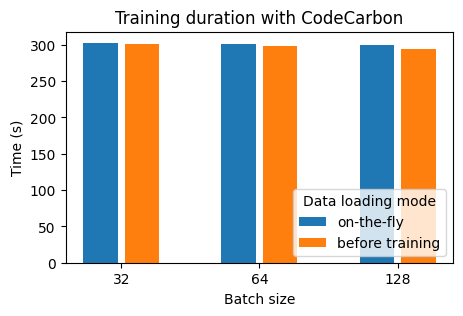

In [43]:
fig, ax = bar_plot_per_mode(data_cc_onfly, data_cc_preload, col_to_plot="duration")

ax.set_xlabel("Batch size")
ax.set_title(f"Training duration with CodeCarbon")
ax.set_ylabel("Time (s)")
ax.legend(title="Data loading mode", loc="lower right")
fig.savefig(os.path.join(plot_dir,  "training_duration_cc.png"), dpi=300, bbox_inches="tight")

CO2 emissions

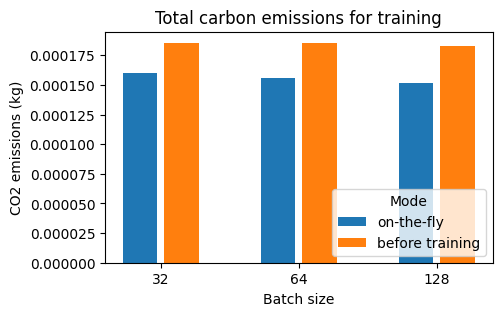

In [44]:
fig, ax = bar_plot_per_mode(data_cc_onfly, data_cc_preload, col_to_plot="emissions")

ax.set_xlabel("Batch size")
ax.set_title(f"Total carbon emissions for training")
ax.set_ylabel("CO2 emissions (kg)")
ax.legend(title="Mode", loc="lower right")
fig.savefig(os.path.join(plot_dir,  "carbon_emissions_train.png"), dpi=300, bbox_inches="tight")

Carbon emission rate -- note that this is is the carbon emissions/duration. It is probably a calculation that CodeCarbon does rather than a measurement. 

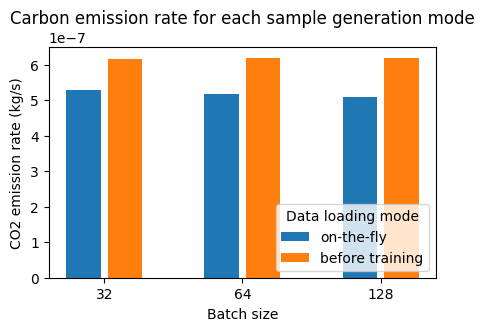

In [45]:
fig, ax = bar_plot_per_mode(data_cc_onfly, data_cc_preload, col_to_plot="emissions_rate")

ax.set_xlabel("Batch size")
ax.set_title(f"Carbon emission rate for each sample generation mode")
ax.set_ylabel("CO2 emission rate (kg/s)")
ax.legend(title="Data loading mode", loc="lower right")
fig.savefig(os.path.join(plot_dir,  "carbon_emissions_rate_train.png"), dpi=300, bbox_inches="tight")

GPU, CPU, RAM power -- these are all averaged

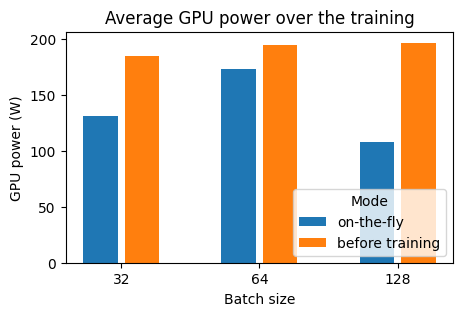

In [46]:
fig, ax = bar_plot_per_mode(data_cc_onfly, data_cc_preload, col_to_plot="gpu_power")

ax.set_xlabel("Batch size")
ax.set_title(f"Average GPU power over the training")
ax.set_ylabel("GPU power (W)")
ax.legend(title="Mode", loc="lower right")
fig.savefig(os.path.join(plot_dir,  "gpu_power_train.png"), dpi=300, bbox_inches="tight")

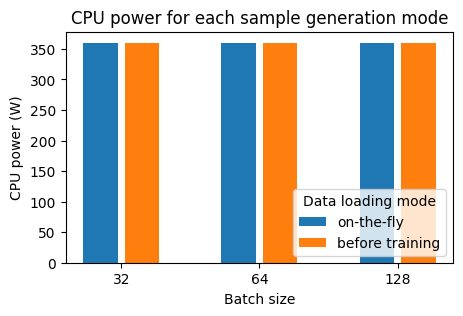

In [47]:
fig, ax = bar_plot_per_mode(data_cc_onfly, data_cc_preload, col_to_plot="cpu_power")

ax.set_xlabel("Batch size")
ax.set_title(f"CPU power for each sample generation mode")
ax.set_ylabel("CPU power (W)")
ax.legend(title="Data loading mode", loc="lower right")
fig.savefig(os.path.join(plot_dir,  "cpu_power_train.png"), dpi=300, bbox_inches="tight")

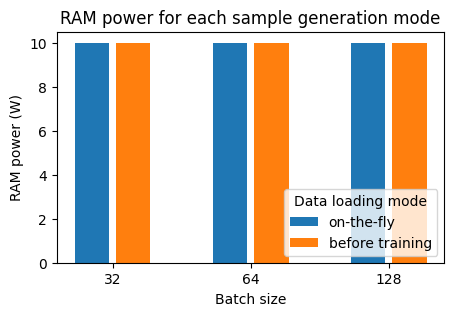

In [48]:
fig, ax = bar_plot_per_mode(data_cc_onfly, data_cc_preload, col_to_plot="ram_power")

ax.set_xlabel("Batch size")
ax.set_title(f"RAM power for each sample generation mode")
ax.set_ylabel("RAM power (W)")
ax.legend(title="Data loading mode", loc="lower right")
fig.savefig(os.path.join(plot_dir,  "ram_power_train.png"), dpi=300, bbox_inches="tight")

Energy

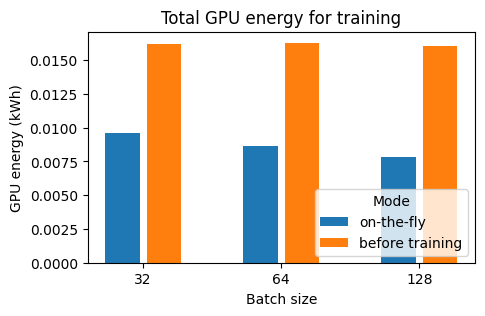

In [49]:
fig, ax = bar_plot_per_mode(data_cc_onfly, data_cc_preload, col_to_plot="gpu_energy")

ax.set_xlabel("Batch size")
ax.set_title(f"Total GPU energy for training")
ax.set_ylabel("GPU energy (kWh)")
ax.legend(title="Mode", loc="lower right")
fig.savefig(os.path.join(plot_dir,  "gpu_energy_train.png"), dpi=300, bbox_inches="tight")

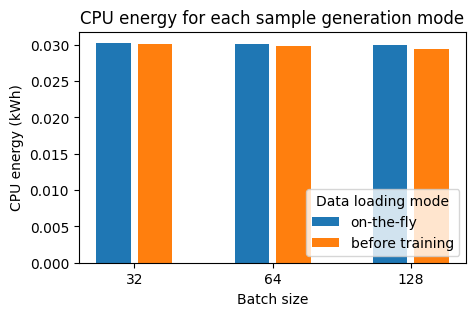

In [50]:
fig, ax = bar_plot_per_mode(data_cc_onfly, data_cc_preload, col_to_plot="cpu_energy")

ax.set_xlabel("Batch size")
ax.set_title(f"CPU energy for each sample generation mode")
ax.set_ylabel("CPU energy (kWh)")
ax.legend(title="Data loading mode", loc="lower right")
fig.savefig(os.path.join(plot_dir,  "cpu_energy_train.png"), dpi=300, bbox_inches="tight")

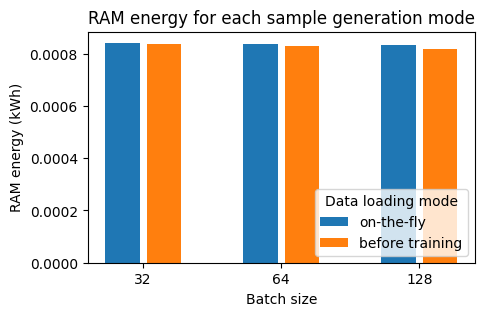

In [51]:
fig, ax = bar_plot_per_mode(data_cc_onfly, data_cc_preload, col_to_plot="ram_energy")

ax.set_xlabel("Batch size")
ax.set_title(f"RAM energy for each sample generation mode")
ax.set_ylabel("RAM energy (kWh)")
ax.legend(title="Data loading mode", loc="lower right")
fig.savefig(os.path.join(plot_dir,  "ram_energy_train.png"), dpi=300, bbox_inches="tight")